In [121]:
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    print("Running in Google Colab")
else:
    print("Running locally or in another environment")

Running locally or in another environment


In [122]:
# Install the ARC-AGI SDK
!pip install -q arc-agi

# Clone the repo (skip if running locally)
import os

if IN_COLAB:
    if not os.path.exists("arc-witness-envs"):
        !git clone https://github.com/Guanghan/arc-witness-envs.git


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip


In [123]:

if os.path.basename(os.getcwd()) != "arc-witness-envs":
    os.chdir("arc-witness-envs")
print(f"Working directory: {os.getcwd()}")

Working directory: /Users/andrewjennings/PyCharmProjects/witness2/arc-witness-envs


In [124]:
print(f"Working directory: {os.getcwd()}")

Working directory: /Users/andrewjennings/PyCharmProjects/witness2/arc-witness-envs


In [125]:
import sys, json, importlib
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from arcengine import GameAction, ActionInput, GameState

UP    = GameAction.ACTION1
DOWN  = GameAction.ACTION2
LEFT  = GameAction.ACTION3
RIGHT = GameAction.ACTION4
CONFIRM = GameAction.ACTION5
RESET = GameAction.RESET

ACTION_NAMES = {1: "UP", 2: "DOWN", 3: "LEFT", 4: "RIGHT", 5: "CONFIRM"}

# 16-color palette (index -> RGB)
PALETTE = {
    0:  [255, 255, 255],  # white
    1:  [204, 204, 204],  # light_gray
    2:  [153, 153, 153],  # gray
    3:  [102, 102, 102],  # dark_gray
    4:  [ 51,  51,  51],  # near_black
    5:  [  0,   0,   0],  # black
    6:  [229,  58, 163],  # magenta
    7:  [255, 123, 204],  # light_magenta
    8:  [249,  60,  49],  # red
    9:  [ 30, 147, 255],  # blue
    10: [136, 216, 241],  # light_blue
    11: [255, 220,   0],  # yellow
    12: [255, 133,  27],  # orange
    13: [146,  18,  49],  # maroon
    14: [ 79, 204,  48],  # green
    15: [163,  86, 214],  # purple
}

# Build matplotlib colormap from the palette
_colors_rgb = [np.array(PALETTE[i]) / 255.0 for i in range(16)]
WITNESS_CMAP = mcolors.ListedColormap(_colors_rgb)


def get_frame(game):
    """Get the current 64x64 grid from a game (as numpy array)."""
    frame_data = game.perform_action(ActionInput(id=RESET), raw=True)
    arr = frame_data.frame[0]
    return np.array(arr) if not isinstance(arr, np.ndarray) else arr


def act(game, action):
    """Perform an action and return (frame_array, frame_data)."""
    fd = game.perform_action(ActionInput(id=action), raw=True)
    arr = fd.frame[0]
    arr = np.array(arr) if not isinstance(arr, np.ndarray) else arr
    return arr, fd


def show_grid(grid, title="", ax=None):
    """Display a 64x64 color-index grid with the Witness palette."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(4, 4))
    ax.imshow(grid, cmap=WITNESS_CMAP, vmin=0, vmax=15,
              interpolation='nearest')
    ax.set_title(title, fontsize=10)
    ax.axis('off')


# Game registry: game_id -> (module_path, class_name)
GAME_REGISTRY = {
    f"tw{i:02d}": (f"environment_files.tw{i:02d}.tw{i:02d}", f"Tw{i:02d}")
    for i in range(1, 14)
}

def load_game(game_id, seed=0):
    """Load and return a game instance by ID."""
    mod_path, cls_name = GAME_REGISTRY[game_id]
    mod = importlib.import_module(mod_path)
    return getattr(mod, cls_name)(seed=seed)

print("Setup complete.")

Setup complete.


## 2. Visualize a Puzzle Level

Each game renders to a **64×64 pixel grid** with 16 indexed colors. Let’s look at the first level of `tw01` (PathDots) — draw a path through all yellow waypoints.

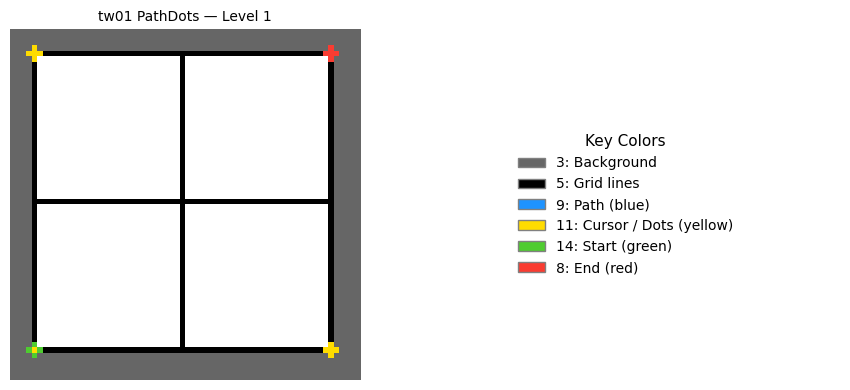

In [126]:
game = load_game("tw01")
grid = get_frame(game)

fig, axes = plt.subplots(1, 2, figsize=(9, 4))

# Left: the rendered grid
show_grid(grid, "tw01 PathDots — Level 1", ax=axes[0])

# Right: palette legend
semantic = {
    3: "Background", 5: "Grid lines", 9: "Path (blue)",
    11: "Cursor / Dots (yellow)", 14: "Start (green)", 8: "End (red)",
}
patches = []
labels = []
for idx, name in semantic.items():
    color = np.array(PALETTE[idx]) / 255.0
    patches.append(plt.Rectangle((0, 0), 1, 1, fc=color, ec='gray'))
    labels.append(f"{idx}: {name}")
axes[1].legend(patches, labels, loc='center', fontsize=10,
               title="Key Colors", title_fontsize=11, frameon=False)
axes[1].axis('off')
plt.tight_layout()
plt.show()

## 3. Step-by-Step Gameplay

Solve `tw01` level 1 by executing actions one at a time. Watch the path grow on the grid.

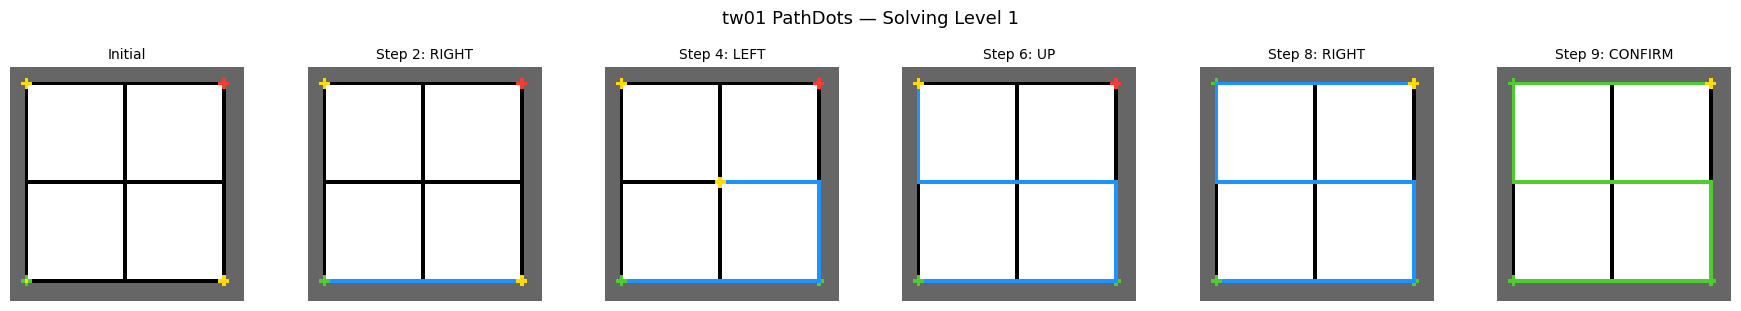

Levels completed: 1
Game state: GameState.NOT_FINISHED


In [127]:
game = load_game("tw01")

# Known solution for tw01 level 1
solution = [RIGHT, RIGHT, UP, LEFT, LEFT, UP, RIGHT, RIGHT, CONFIRM]
action_labels = ["RIGHT", "RIGHT", "UP", "LEFT", "LEFT", "UP", "RIGHT", "RIGHT", "CONFIRM"]

# Collect frames at each step
frames = []
init_grid = get_frame(game)  # reset to get initial state
frames.append(("Start", init_grid.copy()))

for action, label in zip(solution, action_labels):
    grid, fd = act(game, action)
    frames.append((label, grid.copy()))

# Show key frames (every other + last two)
indices = [0, 2, 4, 6, 8, 9]  # Start, step 2, 4, 6, 8(RIGHT), 9(CONFIRM)
fig, axes = plt.subplots(1, len(indices), figsize=(3 * len(indices), 3))
for ax, i in zip(axes, indices):
    label, grid = frames[i]
    step_label = f"Step {i}: {label}" if i > 0 else "Initial"
    show_grid(grid, step_label, ax=ax)

plt.suptitle("tw01 PathDots — Solving Level 1", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"Levels completed: {fd.levels_completed}")
print(f"Game state: {fd.state}")

## 4. All 13 Games at a Glance

Each game implements a different puzzle mechanic mapping to ARC-AGI [Core Knowledge](https://arxiv.org/abs/1911.01547) priors.

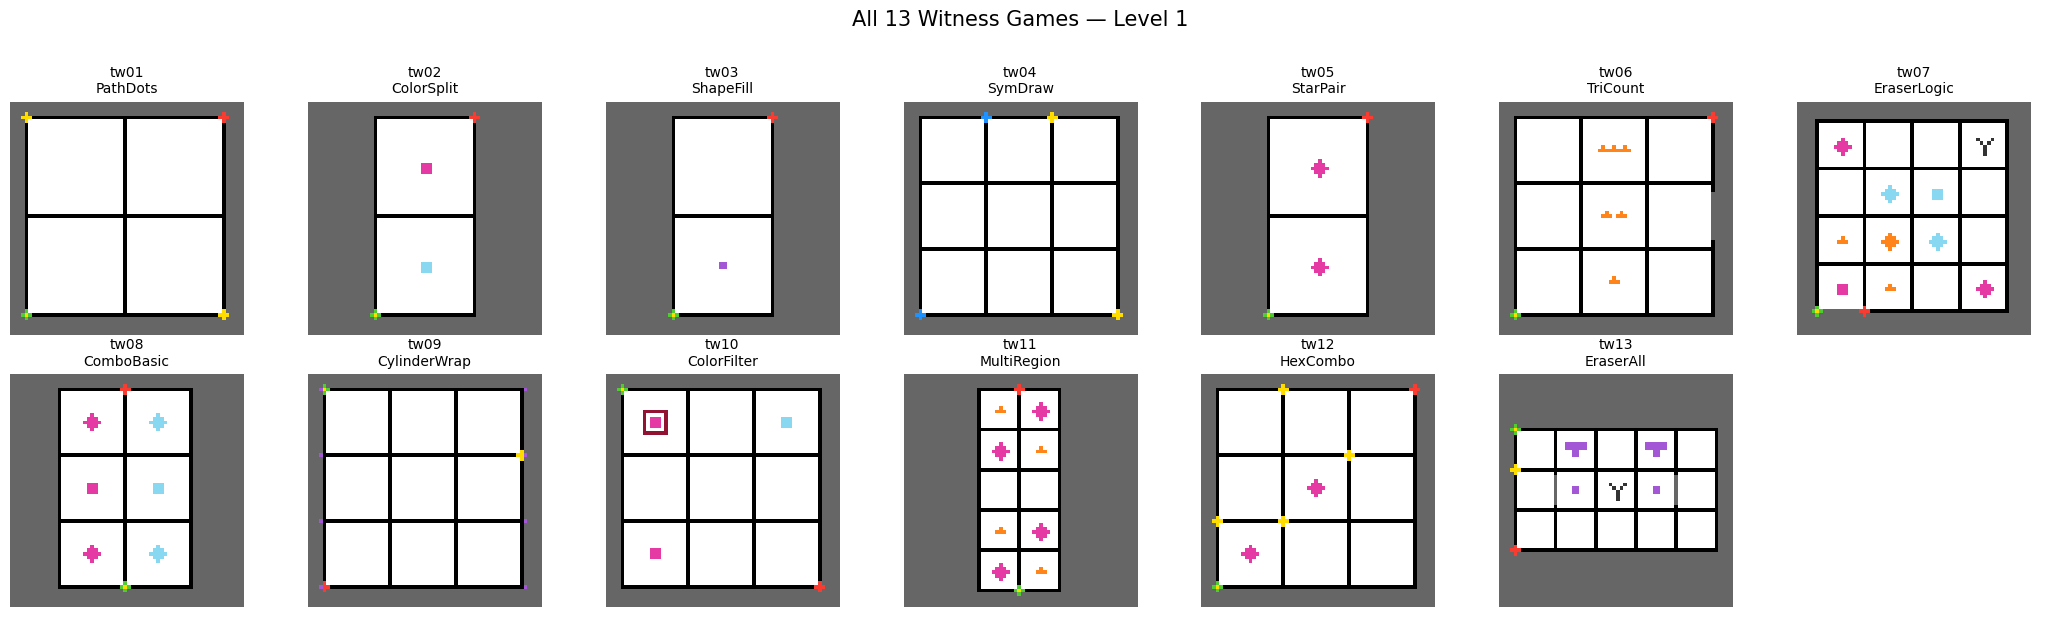

In [128]:
game_titles = {
    "tw01": "PathDots",     "tw02": "ColorSplit",   "tw03": "ShapeFill",
    "tw04": "SymDraw",      "tw05": "StarPair",     "tw06": "TriCount",
    "tw07": "EraserLogic",  "tw08": "ComboBasic",   "tw09": "CylinderWrap",
    "tw10": "ColorFilter",  "tw11": "MultiRegion",  "tw12": "HexCombo",
    "tw13": "EraserAll",
}

fig, axes = plt.subplots(2, 7, figsize=(21, 6))
axes_flat = axes.flatten()

for i, (gid, title) in enumerate(game_titles.items()):
    game = load_game(gid)
    grid = get_frame(game)
    show_grid(grid, f"{gid}\n{title}", ax=axes_flat[i])

# Hide the extra subplot (14th cell in 2x7 grid)
axes_flat[13].axis('off')

plt.suptitle("All 13 Witness Games — Level 1", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

## 5. Dataset Statistics

Levels are stored in `levels/*.json`. Let’s visualize the distribution.

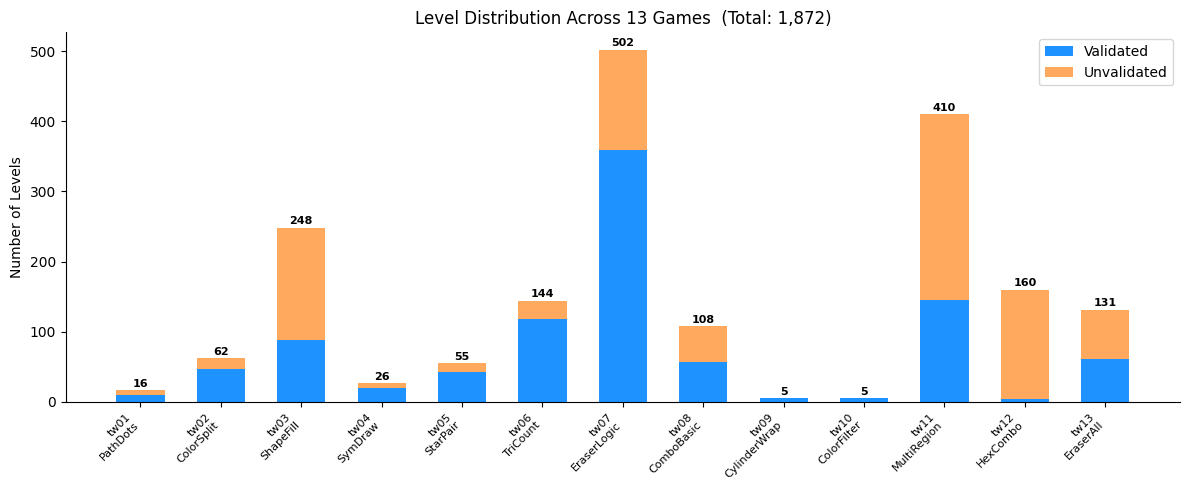

Total: 1,872 levels (959 validated + 913 unvalidated)


In [129]:
stats = []
for gid in game_titles:
    path = f"levels/{gid}_levels.json"
    with open(path) as f:
        data = json.load(f)
    levels = data["levels"]
    validated = sum(1 for lv in levels if lv.get("validated", True))
    unvalidated = len(levels) - validated
    stats.append({"game": gid, "title": game_titles[gid],
                  "validated": validated, "unvalidated": unvalidated,
                  "total": len(levels)})

games = [s["game"] for s in stats]
val   = [s["validated"] for s in stats]
unval = [s["unvalidated"] for s in stats]

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(games))
bar_w = 0.6
ax.bar(x, val, bar_w, label="Validated", color="#1e93ff")
ax.bar(x, unval, bar_w, bottom=val, label="Unvalidated", color="#ff851b", alpha=0.7)

# Annotate totals
for i, s in enumerate(stats):
    ax.text(i, s["total"] + 5, str(s["total"]), ha='center', fontsize=8, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels([f"{s['game']}\n{s['title']}" for s in stats],
                    rotation=45, ha='right', fontsize=8)
ax.set_ylabel("Number of Levels")
ax.set_title(f"Level Distribution Across 13 Games  (Total: {sum(s['total'] for s in stats):,})")
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print(f"Total: {sum(s['total'] for s in stats):,} levels "
      f"({sum(val)} validated + {sum(unval)} unvalidated)")

In [130]:
import numpy as np
from typing import List, Tuple, Dict, Set, Optional


# ============================================
# ARC-AGI-3 Color Palette (0-15)
# ============================================

class ARCColor:
    """Color indices for ARC-AGI-3 16-color palette"""
    BLACK = 0
    WHITE = 1
    RED = 2
    GREEN = 3
    BLUE = 4
    YELLOW = 5
    CYAN = 6
    MAGENTA = 7
    BROWN = 8
    PINK = 9
    DARK_GREEN = 10
    ORANGE = 11
    PURPLE = 12
    LIGHT_BLUE = 13
    LIGHT_GREEN = 14
    LIGHT_GRAY = 15

# Map color indices to human-readable names
COLOR_NAMES = {
    ARCColor.BLACK: "background",
    ARCColor.WHITE: "cursor/agent",
    ARCColor.RED: "end_goal",
    ARCColor.GREEN: "start_point",
    ARCColor.BLUE: "water/obstacle",
    ARCColor.YELLOW: "waypoint",
    ARCColor.CYAN: "path",
    ARCColor.MAGENTA: "enemy",
    ARCColor.BROWN: "wall",
    ARCColor.PINK: "reward",
    ARCColor.DARK_GREEN: "forest",
    ARCColor.ORANGE: "key",
    ARCColor.PURPLE: "door",
    ARCColor.LIGHT_BLUE: "path",
    ARCColor.LIGHT_GREEN: "grass",
    ARCColor.LIGHT_GRAY: "neutral"
}

# ============================================
# TRADITIONAL COMPUTER VISION DETECTOR
# ============================================

class TraditionalObjectDetector:
    """
    Detects objects in ARC-AGI-3 grids using color-based segmentation.
    This is the fastest and most reliable method for ARC games.
    """

    def __init__(self, grid_size: int = 64):
        self.grid_size = grid_size
        self.min_object_size = 2  # Minimum pixels to consider as object

    def detect_objects(self, frame: np.ndarray) -> Dict[str, List[Tuple[int, int]]]:
        """
        Detect objects in the frame.

        Args:
            frame: 64x64 numpy array of color indices (0-15)

        Returns:
            Dictionary mapping object type to list of (x, y) positions
        """
        objects = {
            'agent': [],
            'start': [],
            'end': [],
            'waypoints': [],
            'path': [],
            'walls': [],
            'keys': [],
            'doors': [],
            'rewards': []
        }


        # Method 1: Direct color lookup (fastest)
        for y in range(self.grid_size):
            for x in range(self.grid_size):
                color = frame[y, x]

                if color == ARCColor.WHITE:
                    objects['agent'].append((x, y))
                elif color == ARCColor.GREEN:
                    objects['start'].append((x, y))
                elif color == ARCColor.RED:
                    objects['end'].append((x, y))
                elif color == ARCColor.YELLOW:
                    objects['waypoints'].append((x, y))
                elif color in [ARCColor.CYAN, ARCColor.LIGHT_BLUE]:
                    objects['path'].append((x, y))
                elif color == ARCColor.BLACK:
                    continue
                elif color == ARCColor.BROWN:
                    objects['walls'].append((x, y))
                elif color == ARCColor.ORANGE:
                    objects['keys'].append((x, y))
                elif color == ARCColor.PURPLE:
                    objects['doors'].append((x, y))
                elif color == ARCColor.PINK:
                    objects['rewards'].append((x, y))

        return objects

    def find_connected_components(self, frame: np.ndarray, target_color: int) -> List[List[Tuple[int, int]]]:
        """
        Find connected components of a specific color using flood fill.
        Useful for grouping adjacent pixels into distinct objects.
        """
        visited = np.zeros_like(frame, dtype=bool)
        components = []

        for y in range(self.grid_size):
            for x in range(self.grid_size):
                if frame[y, x] == target_color and not visited[y, x]:
                    # Flood fill to find connected component
                    component = []
                    stack = [(x, y)]

                    while stack:
                        cx, cy = stack.pop()
                        if visited[cy, cx]:
                            continue
                        visited[cy, cx] = True
                        component.append((cx, cy))

                        # Check 4-connected neighbors
                        for dx, dy in [(1 ,0), (-1 ,0), (0 ,1), (0 ,-1)]:
                            nx, ny = cx + dx, cy + dy
                            if 0 <= nx < self.grid_size and 0 <= ny < self.grid_size:
                                if frame[ny, nx] == target_color and not visited[ny, nx]:
                                    stack.append((nx, ny))

                    if len(component) >= self.min_object_size:
                        components.append(component)

        return components

    def get_object_centroids(self, objects: Dict) -> Dict[str, List[Tuple[float, float]]]:
        """Calculate centroids of detected objects"""
        centroids = {}

        for obj_type, positions in objects.items():
            if positions:
                # Group positions into components if needed
                # For now, just calculate average
                xs = [p[0] for p in positions]
                ys = [p[1] for p in positions]
                centroids[obj_type] = [(sum(xs ) /len(xs), sum(ys ) /len(ys))]
            else:
                centroids[obj_type] = []

        return centroids



In [131]:

# ============================================
# INTEGRATION WITH ARC-AGI-3 ENVIRONMENT
# ============================================

class ARCObservationParser:
    """
    Parse ARC-AGI-3 environment observations into structured game state.
    """

    def __init__(self, use_cnn: bool = False):
        self.detector = TraditionalObjectDetector()

    def parse_observation(self, obs) -> Dict:
        """
        Parse frame from ARC-AGI-3 environment.

        Args:
            obs: FrameDataRaw object from env.reset() or env.step()

        Returns:
            Structured game state
        """
        # Extract grid
        if hasattr(obs, 'frame'):
            frame = obs.frame
        elif hasattr(obs, 'grid'):
            frame = obs.grid
        else:
            raise ValueError("Observation has no 'frame' or 'grid' attribute")

        # Detect objects
        objects = self.detector.detect_objects(frame)

        # Extract metadata
        metadata = {
            'state': getattr(obs, 'state', None),
            'levels_completed': getattr(obs, 'levels_completed', 0),
            'win_levels': getattr(obs, 'win_levels', 0)
        }

        # Build structured state
        game_state = {
            'frame': frame,
            'objects': objects,
            'agent_pos': objects.get('agent', [None])[0],
            'start_pos': objects.get('start', [None])[0],
            'end_pos': objects.get('end', [None])[0],
            'waypoints': objects.get('waypoints', []),
            'path': objects.get('path', []),
            'walls': objects.get('walls', []),
            'keys': objects.get('keys', []),
            'doors': objects.get('doors', []),
            'rewards': objects.get('rewards', []),
            'metadata': metadata
        }

        return game_state


In [132]:
def demo_detection():
    """Demonstrate object detection on a synthetic frame"""

    # Create synthetic 64x64 frame
    frame = np.full((64, 64), ARCColor.BLACK, dtype=np.uint8)

    # Add some objects
    frame[10, 10] = ARCColor.GREEN      # Start
    frame[50, 50] = ARCColor.RED        # End
    frame[20, 20] = ARCColor.YELLOW     # Waypoint
    frame[30, 30] = ARCColor.YELLOW     # Another waypoint
    frame[15, 10] = ARCColor.WHITE      # Agent
    frame[25:30, 40:45] = ARCColor.CYAN # Path

    # Initialise detector
    detector = TraditionalObjectDetector()

    # Detect objects
    objects = detector.detect_objects(frame)

    print("=== Detected Objects ===")
    for obj_type, positions in objects.items():
        if positions:
            print(f"{obj_type}: {positions[:5]}..." if len(positions) > 5 else f"{obj_type}: {positions}")

    # Calculate centroids
    centroids = detector.get_object_centroids(objects)
    print("\n=== Object Centroids ===")
    for obj_type, centroid in centroids.items():
        if centroid:
            print(f"{obj_type}: {centroid[0]}")


In [133]:
def basic_object_detection(frame):
    """Demonstrate object detection on a frame"""


    # Initialise detector
    detector = TraditionalObjectDetector()

    # Detect objects
    objects = detector.detect_objects(frame)

    print("=== Detected Objects ===")
    for obj_type, positions in objects.items():
        if positions:
            print(f"{obj_type}: {positions[:5]}..." if len(positions) > 5 else f"{obj_type}: {positions}")

    # Calculate centroids
    centroids = detector.get_object_centroids(objects)
    print("\n=== Object Centroids ===")
    for obj_type, centroid in centroids.items():
        if centroid:
            print(f"{obj_type}: {centroid[0]}")

## 6. Random Agent Explore Object Recognition

How hard are these puzzles? Let’s run a **random agent** that picks uniformly from the 5 actions. Spoiler: it almost never solves anything — showing that these puzzles require genuine reasoning.

In [134]:
import random

ACTIONS = [UP, DOWN, LEFT, RIGHT, CONFIRM]

def arc_random_agent_episode(env, max_steps=200):
    """Run one episode with random actions. Returns (solved, steps)."""
    fd = env.reset()
    initial_completed = fd.levels_completed

    for step in range(1, max_steps + 1):
        action = random.choice(ACTIONS)
        fd = env.step(action)
        grid = np.array(fd.frame[0], dtype=np.uint8)
        basic_object_detection(grid)
        if fd.levels_completed > initial_completed:
            return True, step
    return False, max_steps

In [135]:
from arc_agi import Arcade, OperationMode

arcade = Arcade(
    operation_mode=OperationMode.OFFLINE,
    environments_dir="environment_files",
)

# Your agent sees tw01-tw13 exactly like official ARC-AGI-3 games
for env_info in arcade.get_environments():
    print(env_info.game_id, env_info.title)

scorecard_id = arcade.create_scorecard(tags=["witness"])
env = arcade.make(game_id="tw03", scorecard_id=scorecard_id)
obs = env.reset()

results = {}
n_episodes = 10
max_steps = 20

solves = 0
total_steps = 0
for _ in range(n_episodes):
    # Reset to level 1 each episode
    solved, steps = arc_random_agent_episode(env, max_steps)
    solves += solved
    total_steps += steps
results[gid] = {
    "solve_rate": solves / n_episodes,
    "avg_steps": total_steps / n_episodes,
}
print(f"{gid} ({game_titles[gid]}): "
      f"solve rate = {solves}/{n_episodes} ({100*solves/n_episodes:.1f}%), "
      f"avg steps = {total_steps/n_episodes:.1f}")

INFO:arc_agi.scorecard:Initialized ScorecardManager with idle_for=0:15:00 and max_open_for=3 days, 0:00:00
tw08 ComboBasic - 基础组合
tw01 PathDots - 路径必经点
tw06 TriCount - 三角形计数
tw07 EraserLogic - 消除逻辑
tw09 CylinderWrap - 圆柱环绕
tw13 EraserAll - 全约束消除逻辑
tw12 HexCombo - 必经点+区域组合
tw05 StarPair - 星星配对
tw02 ColorSplit - 彩色方块分隔
tw03 ShapeFill - 多联骨牌铺满
tw04 SymDraw - 对称画线
tw10 ColorFilter - 颜色滤镜
tw11 MultiRegion - 多约束区域组合
2026-05-05 11:03:01 | INFO | Created new scorecard: 808ca192-8dae-4f12-8991-4d37965c6ba2
2026-05-05 11:03:01 | INFO | Found latest version of tw03: tw03 (downloaded: 2026-03-05 00:00:00+00:00)
[array([[3, 3, 3, ..., 3, 3, 3],
       [3, 3, 3, ..., 3, 3, 3],
       [3, 3, 3, ..., 3, 3, 3],
       ...,
       [3, 3, 3, ..., 3, 3, 3],
       [3, 3, 3, ..., 3, 3, 3],
       [3, 3, 3, ..., 3, 3, 3]], shape=(64, 64), dtype=int8)]
=== Detected Objects ===
start: [(0, 0), (1, 0), (2, 0), (3, 0), (4, 0)]...
waypoints: [(18, 4), (19, 4), (20, 4), (21, 4), (22, 4)]...
walls: [(45, 3), (44, 

## 7. Plug In Your Own Agent

Replace the `my_agent` function below with your own policy. The interface is simple:
- **Observation**: 64×64 int array (color indices 0–15)
- **Action**: one of 5 discrete actions (UP / DOWN / LEFT / RIGHT / CONFIRM)

Not solved in 50 steps. Keep improving your agent!


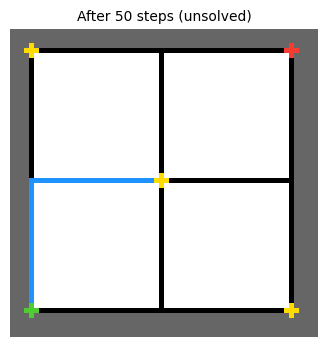

In [136]:
def my_agent(observation: np.ndarray) -> GameAction:
    """
    Your agent here.

    Args:
        observation: 64x64 numpy array of color indices (0-15)

    Returns:
        GameAction: one of ACTION1 (UP), ACTION2 (DOWN),
                    ACTION3 (LEFT), ACTION4 (RIGHT), ACTION5 (CONFIRM)
    """

    return random.choice(ACTIONS)


# Run your agent on tw01
game = load_game("tw01")
fd = game.perform_action(ActionInput(id=RESET), raw=True)
initial_grid = np.array(fd.frame[0])

max_steps = 50
for step in range(max_steps):
    action = my_agent(initial_grid)
    grid, fd = act(game, action)
    initial_grid = grid

    if fd.levels_completed > 0:
        print(f"Level solved in {step + 1} steps!")
        show_grid(grid, f"Solved in {step+1} steps")
        plt.show()
        break
else:
    print(f"Not solved in {max_steps} steps. Keep improving your agent!")
    show_grid(grid, f"After {max_steps} steps (unsolved)")
    plt.show()

---

**Next steps:**
- Try the [OpenEnv adapter](https://github.com/Guanghan/arc-witness-envs#openenv-adapter-rl-training) for RL training (PPO, DQN, RND)
- Use `Arcade` from `arc-agi` SDK to [load these as ARC-AGI-3 environments](https://github.com/Guanghan/arc-witness-envs#arc-agi-3-integration)
- Play in the browser: `python play_human.py` → http://localhost:8001